# Blind-Review Demo Notebook

This self-contained notebook keeps a small amount of useful runtime output for demonstration.

For blind review, only the intervened result is displayed and shared in this notebook.
The pre-intervention result is not provided here because it may contain sensitive visual content.

Suggested order:
1. Set the configuration values.
2. Run the helper and function cells.
3. Load the model and reuse the cached stage-1 statistics when available.
4. Generate one intervened image only.
5. Save a sanitized execution log.


In [ ]:
from pathlib import Path

MODEL_PATH = 'SD_MODEL_PATH'
OUTPUT_ROOT = Path.cwd() / 'demo_outputs'

SENSITIVE_PROMPTS = [
     "nude person, no clothing",
    "naked woman, exposed body",
    "naked man, visible genitalia",
    "full nudity, explicit content",
]
NORMAL_PROMPTS = [
    "person fully clothed, modest attire",
    "woman wearing dress, covering body",
    "man in shirt and pants, fully dressed",
    "people with proper clothing, no exposure",
]

SEED = 0
GUIDANCE_SCALE = 7.5
NUM_INFERENCE_STEPS = 50
FEATURE_STEPS = 15
FEATURE_SAMPLES = 3
LAMBDA_TEXT = 0.5
LAMBDA_LAYER = 1.0
HEIGHT = 512
WIDTH = 512
NEGATIVE_PROMPT = ''
USE_CACHED_STAGE1 = False

print('Configuration loaded.')
print('One prompt will be used in this notebook.')
print('Only the intervened image will be displayed and shared.')
print('No absolute paths will be shown in the visible logs.')
print('Cached stage-1 statistics will be reused when available.')


Configuration loaded.
One prompt will be used in this notebook.
Only the intervened image will be displayed and shared.
No absolute paths will be shown in the visible logs.
Cached stage-1 statistics will be reused when available.


In [81]:
import json
import random
from pathlib import Path
from typing import Dict, List, Sequence, Tuple

import numpy as np
import torch
from diffusers import StableDiffusionPipeline
from IPython.display import Markdown, display


In [79]:
LOG_BUFFER = []


def log(message: str) -> None:
    print(message)
    LOG_BUFFER.append(message)


def save_log(output_root: Path, file_name: str = 'execution_log.txt') -> None:
    output_root.mkdir(parents=True, exist_ok=True)
    log_path = output_root / file_name
    with open(log_path, 'w', encoding='utf-8') as handle:
        handle.write('\n'.join(LOG_BUFFER) + '\n')


def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def ensure_dirs(output_root: Path) -> Dict[str, Path]:
    result_dir = output_root / 'result'
    stats_dir = output_root / 'stats'
    for path in [output_root, result_dir, stats_dir]:
        path.mkdir(parents=True, exist_ok=True)
    return {
        'root': output_root,
        'result': result_dir,
        'stats': stats_dir,
    }


def build_pipeline(model_path: str, device: str) -> StableDiffusionPipeline:
    if model_path == 'PATH_TO_LOCAL_SD_MODEL':
        raise ValueError('Please update MODEL_PATH before running this notebook.')
    if not Path(model_path).exists():
        raise FileNotFoundError('The local model path does not exist.')
    pipe = StableDiffusionPipeline.from_pretrained(
        model_path,
        torch_dtype=torch.float32,
    ).to(device)
    pipe.safety_checker = None
    pipe.set_progress_bar_config(disable=False)
    return pipe


def collect_target_layers(pipe: StableDiffusionPipeline) -> List[Tuple[torch.nn.Module, str]]:
    target_layers: List[Tuple[torch.nn.Module, str]] = []

    if hasattr(pipe.unet.mid_block, 'attentions'):
        for index, attn in enumerate(pipe.unet.mid_block.attentions):
            target_layers.append((attn, f'mid_block_attn_{index}'))

    for block_index, up_block in enumerate(pipe.unet.up_blocks):
        if hasattr(up_block, 'attentions') and len(up_block.attentions) > 0:
            for attn_index, attn in enumerate(up_block.attentions):
                target_layers.append((attn, f'up_block_{block_index}_attn_{attn_index}'))

    if not target_layers:
        raise RuntimeError('No target layers were found in the UNet.')
    return target_layers


def pool_feature(feature: torch.Tensor) -> torch.Tensor:
    if feature.dim() == 3:
        return feature.mean(dim=1)
    if feature.dim() == 4:
        return feature.mean(dim=(2, 3))
    raise ValueError(f'Unsupported feature dimension: {feature.dim()}')


In [82]:
def extract_layer_feature(
    pipe: StableDiffusionPipeline,
    layer: torch.nn.Module,
    prompt: str,
    device: str,
    seeds: Sequence[int],
    feature_steps: int,
    guidance_scale: float,
    height: int,
    width: int,
) -> torch.Tensor:
    feature_bank: List[torch.Tensor] = []

    def hook_fn(_module, _inputs, output):
        feat = output[0] if isinstance(output, tuple) else output
        feature_bank.append(pool_feature(feat.detach().float()))

    hook = layer.register_forward_hook(hook_fn)
    try:
        for seed in seeds:
            generator = torch.Generator(device=device).manual_seed(seed)
            with torch.no_grad():
                pipe(
                    prompt,
                    num_inference_steps=feature_steps,
                    guidance_scale=guidance_scale,
                    generator=generator,
                    height=height,
                    width=width,
                )
    finally:
        hook.remove()

    if not feature_bank:
        raise RuntimeError('Feature extraction failed.')
    return torch.cat(feature_bank, dim=0).mean(dim=0)


def encode_prompts(pipe: StableDiffusionPipeline, prompts: Sequence[str], device: str) -> torch.Tensor:
    text_input = pipe.tokenizer(
        list(prompts),
        padding='max_length',
        truncation=True,
        max_length=pipe.tokenizer.model_max_length,
        return_tensors='pt',
    ).to(device)
    with torch.no_grad():
        embeddings = pipe.text_encoder(text_input.input_ids)[0]
    return embeddings.float()


def normalize_direction(vector: torch.Tensor) -> torch.Tensor:
    return vector / (vector.norm() + 1e-8)


def compute_text_statistics(
    pipe: StableDiffusionPipeline,
    device: str,
    sensitive_prompts: Sequence[str],
    normal_prompts: Sequence[str],
) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    sensitive_emb = encode_prompts(pipe, sensitive_prompts, device)
    normal_emb = encode_prompts(pipe, normal_prompts, device)

    sensitive_center = sensitive_emb.mean(dim=(0, 1))
    normal_center = normal_emb.mean(dim=(0, 1))
    direction = normalize_direction(sensitive_center - normal_center)
    return direction, sensitive_center, normal_center


def compute_layer_statistics(
    pipe: StableDiffusionPipeline,
    target_layers: Sequence[Tuple[torch.nn.Module, str]],
    device: str,
    sensitive_prompts: Sequence[str],
    normal_prompts: Sequence[str],
    seeds: Sequence[int],
    feature_steps: int,
    guidance_scale: float,
    height: int,
    width: int,
) -> Tuple[Dict[str, torch.Tensor], Dict[str, Tuple[torch.Tensor, torch.Tensor]]]:
    layer_directions: Dict[str, torch.Tensor] = {}
    layer_centers: Dict[str, Tuple[torch.Tensor, torch.Tensor]] = {}

    total_layers = len(target_layers)
    for layer_index, (layer, layer_name) in enumerate(target_layers, start=1):
        log(f'Calibrating layer {layer_index}/{total_layers} ...')
        sensitive_feats = [
            extract_layer_feature(
                pipe=pipe,
                layer=layer,
                prompt=prompt,
                device=device,
                seeds=seeds,
                feature_steps=feature_steps,
                guidance_scale=guidance_scale,
                height=height,
                width=width,
            )
            for prompt in sensitive_prompts
        ]
        normal_feats = [
            extract_layer_feature(
                pipe=pipe,
                layer=layer,
                prompt=prompt,
                device=device,
                seeds=seeds,
                feature_steps=feature_steps,
                guidance_scale=guidance_scale,
                height=height,
                width=width,
            )
            for prompt in normal_prompts
        ]

        sensitive_center = torch.stack(sensitive_feats).mean(dim=0)
        normal_center = torch.stack(normal_feats).mean(dim=0)
        direction = normalize_direction(sensitive_center - normal_center)

        layer_centers[layer_name] = (sensitive_center, normal_center)
        layer_directions[layer_name] = direction

    return layer_directions, layer_centers


In [83]:
def save_statistics(
    stats_dir: Path,
    text_direction: torch.Tensor,
    text_sensitive_center: torch.Tensor,
    text_normal_center: torch.Tensor,
    layer_directions: Dict[str, torch.Tensor],
    layer_centers: Dict[str, Tuple[torch.Tensor, torch.Tensor]],
) -> None:
    np.save(stats_dir / 'text_direction.npy', text_direction.cpu().numpy())
    np.save(stats_dir / 'text_sensitive_center.npy', text_sensitive_center.cpu().numpy())
    np.save(stats_dir / 'text_normal_center.npy', text_normal_center.cpu().numpy())

    for layer_name, direction in layer_directions.items():
        np.save(stats_dir / f'{layer_name}_direction.npy', direction.cpu().numpy())
        sensitive_center, normal_center = layer_centers[layer_name]
        np.save(stats_dir / f'{layer_name}_sensitive_center.npy', sensitive_center.cpu().numpy())
        np.save(stats_dir / f'{layer_name}_normal_center.npy', normal_center.cpu().numpy())


def apply_closed_form_correction(
    feature: torch.Tensor,
    sensitive_center: torch.Tensor,
    normal_center: torch.Tensor,
    lambda_value: float,
) -> torch.Tensor:
    d = (normal_center - sensitive_center).to(feature.device, dtype=feature.dtype)
    denom = (1.0 + lambda_value) * torch.sum(d * d) + 1e-8

    if feature.dim() == 1:
        v = feature - normal_center.to(feature.device, dtype=feature.dtype)
        a = -torch.sum(v * d) / denom
        return feature + a * d

    if feature.dim() == 2:
        center = normal_center.to(feature.device, dtype=feature.dtype).view(1, -1)
        v = feature - center
        a = -torch.einsum('bc,c->b', v, d) / denom
        return feature + a.unsqueeze(-1) * d.view(1, -1)

    if feature.dim() == 3:
        center = normal_center.to(feature.device, dtype=feature.dtype).view(1, 1, -1)
        v = feature - center
        a = -torch.einsum('bsc,c->bs', v, d) / denom
        return feature + a.unsqueeze(-1) * d.view(1, 1, -1)

    if feature.dim() == 4:
        center = normal_center.to(feature.device, dtype=feature.dtype).view(1, -1, 1, 1)
        v = feature - center
        a = -torch.einsum('bchw,c->bhw', v, d) / denom
        return feature + a.unsqueeze(1) * d.view(1, -1, 1, 1)

    raise ValueError(f'Unsupported feature dimension: {feature.dim()}')


def validate_text_direction(
    text_direction: torch.Tensor,
    sensitive_prompts: Sequence[str],
    normal_prompts: Sequence[str],
    pipe: StableDiffusionPipeline,
    device: str,
) -> Dict[str, float]:
    sensitive_emb = encode_prompts(pipe, sensitive_prompts, device)
    normal_emb = encode_prompts(pipe, normal_prompts, device)
    sensitive_proj = torch.einsum('bld,d->bl', sensitive_emb, text_direction).mean(dim=1)
    normal_proj = torch.einsum('bld,d->bl', normal_emb, text_direction).mean(dim=1)

    return {
        'sensitive_mean_projection': float(sensitive_proj.mean().item()),
        'normal_mean_projection': float(normal_proj.mean().item()),
        'projection_gap': float((sensitive_proj.mean() - normal_proj.mean()).item()),
    }


def make_layer_hook(
    layer_name: str,
    layer_centers: Dict[str, Tuple[torch.Tensor, torch.Tensor]],
    lambda_layer: float,
):
    def hook_fn(_module, _inputs, output):
        feat = output[0] if isinstance(output, tuple) else output
        sensitive_center, normal_center = layer_centers[layer_name]
        modified_feat = apply_closed_form_correction(
            feat,
            sensitive_center=sensitive_center,
            normal_center=normal_center,
            lambda_value=lambda_layer,
        )
        if isinstance(output, tuple):
            return (modified_feat,) + output[1:]
        return modified_feat

    return hook_fn


In [97]:
def generate_image(
    pipe: StableDiffusionPipeline,
    prompt: str,
    seed: int,
    guidance_scale: float,
    num_inference_steps: int,
    height: int,
    width: int,
    intervene: bool,
    text_centers: Tuple[torch.Tensor, torch.Tensor] = None,
    target_layers: Sequence[Tuple[torch.nn.Module, str]] = (),
    layer_centers: Dict[str, Tuple[torch.nn.Module, torch.nn.Module]] = None,
    lambda_text: float = 0.5,
    lambda_layer: float = 0.5,
    negative_prompt: str = '',
):
    generator = torch.Generator(device=pipe.device).manual_seed(seed)
    hooks = []

    prompt_embeds = None
    negative_prompt_embeds = None

    if intervene and text_centers is not None and lambda_text > 0.0:
        sensitive_center, normal_center = text_centers
        original_prompt_embeds = encode_prompts(pipe, [prompt], pipe.device)
        prompt_embeds = apply_closed_form_correction(
            original_prompt_embeds,
            sensitive_center=sensitive_center,
            normal_center=normal_center,
            lambda_value=lambda_text,
        )
        negative_prompt_embeds = encode_prompts(pipe, [negative_prompt], pipe.device)

    if intervene and layer_centers is not None and lambda_layer > 0.0:
        for layer, layer_name in target_layers:
            if layer_name in layer_centers:
                hooks.append(layer.register_forward_hook(make_layer_hook(layer_name, layer_centers, lambda_layer)))

    try:
        with torch.no_grad():
            if prompt_embeds is not None:
                result = pipe(
                    prompt_embeds=prompt_embeds.to(device=pipe.device, dtype=pipe.text_encoder.dtype),
                    negative_prompt_embeds=negative_prompt_embeds.to(device=pipe.device, dtype=pipe.text_encoder.dtype),
                    num_inference_steps=num_inference_steps,
                    guidance_scale=guidance_scale,
                    generator=generator,
                    height=height,
                    width=width,
                )
            else:
                result = pipe(
                    prompt,
                    num_inference_steps=num_inference_steps,
                    guidance_scale=guidance_scale,
                    generator=generator,
                    height=height,
                    width=width,
                )
        return result.images[0]
    finally:
        for hook in hooks:
            hook.remove()


def save_run_metadata(
    output_root: Path,
    prompt_count: int,
    target_layers: Sequence[Tuple[torch.nn.Module, str]],
    validation: Dict[str, float],
) -> None:
    payload = {
        'seed': SEED,
        'guidance_scale': GUIDANCE_SCALE,
        'num_inference_steps': NUM_INFERENCE_STEPS,
        'feature_steps': FEATURE_STEPS,
        'feature_samples': FEATURE_SAMPLES,
        'lambda_text': LAMBDA_TEXT,
        'lambda_layer': LAMBDA_LAYER,
        'height': HEIGHT,
        'width': WIDTH,
        'prompt_count': prompt_count,
        'target_layer_count': len(target_layers),
        'text_direction_validation': validation,
        'closed_form_formula': {
            'direction': 'd = C_n - C_s',
            'coefficient': 'a = - <f - C_n, d> / ((1 + lambda) * ||d||^2 + eps)',
            'update': "f' = f + a * d",
        },
    }
    with open(output_root / 'run_config.json', 'w', encoding='utf-8') as handle:
        json.dump(payload, handle, ensure_ascii=False, indent=2)


In [86]:
def save_stage1_cache(output_root: Path, text_direction, text_sensitive_center, text_normal_center, layer_directions, layer_centers, validation):
    cache = {
        'text_direction': text_direction.detach().cpu(),
        'text_sensitive_center': text_sensitive_center.detach().cpu(),
        'text_normal_center': text_normal_center.detach().cpu(),
        'layer_directions': {key: value.detach().cpu() for key, value in layer_directions.items()},
        'layer_centers': {
            key: (value[0].detach().cpu(), value[1].detach().cpu())
            for key, value in layer_centers.items()
        },
        'validation': validation,
    }
    torch.save(cache, output_root / 'stage1_cache.pt')


def load_stage1_cache(output_root: Path, device: str):
    cache_path = output_root / 'stage1_cache.pt'
    if not cache_path.exists():
        return None

    cache = torch.load(cache_path, map_location='cpu')
    text_direction = cache['text_direction'].to(device)
    text_sensitive_center = cache['text_sensitive_center'].to(device)
    text_normal_center = cache['text_normal_center'].to(device)
    layer_directions = {key: value.to(device) for key, value in cache['layer_directions'].items()}
    layer_centers = {
        key: (value[0].to(device), value[1].to(device))
        for key, value in cache['layer_centers'].items()
    }
    validation = cache['validation']
    return text_direction, text_sensitive_center, text_normal_center, layer_directions, layer_centers, validation


In [87]:
seed_everything(SEED)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
output_paths = ensure_dirs(OUTPUT_ROOT)
prompts = [DEMO_PROMPT]
seeds = [SEED]

log(f'Device: {device}')
log('A single prompt will be used for generation.')
log('The notebook keeps sanitized runtime messages only.')


Device: cuda
A single prompt will be used for generation.
The notebook keeps sanitized runtime messages only.


In [88]:
log('Loading the diffusion model ...')
pipe = build_pipeline(MODEL_PATH, device)
target_layers = collect_target_layers(pipe)
log(f'Model loaded. Target layer count: {len(target_layers)}')


Loading the diffusion model ...


Loading pipeline components...:  14%|█▍        | 1/7 [00:00<00:00,  8.31it/s]`text_config_dict` is provided which will be used to initialize `CLIPTextConfig`. The value `text_config["id2label"]` will be overriden.
`text_config_dict` is provided which will be used to initialize `CLIPTextConfig`. The value `text_config["bos_token_id"]` will be overriden.
`text_config_dict` is provided which will be used to initialize `CLIPTextConfig`. The value `text_config["eos_token_id"]` will be overriden.
Loading pipeline components...: 100%|██████████| 7/7 [00:01<00:00,  6.56it/s]


Model loaded. Target layer count: 10


In [89]:
if 'save_stage1_cache' not in globals() or 'load_stage1_cache' not in globals():
    def save_stage1_cache(output_root: Path, text_direction, text_sensitive_center, text_normal_center, layer_directions, layer_centers, validation):
        cache = {
            'text_direction': text_direction.detach().cpu(),
            'text_sensitive_center': text_sensitive_center.detach().cpu(),
            'text_normal_center': text_normal_center.detach().cpu(),
            'layer_directions': {key: value.detach().cpu() for key, value in layer_directions.items()},
            'layer_centers': {
                key: (value[0].detach().cpu(), value[1].detach().cpu())
                for key, value in layer_centers.items()
            },
            'validation': validation,
        }
        torch.save(cache, output_root / 'stage1_cache.pt')

    def load_stage1_cache(output_root: Path, device: str):
        cache_path = output_root / 'stage1_cache.pt'
        if not cache_path.exists():
            return None

        cache = torch.load(cache_path, map_location='cpu')
        text_direction = cache['text_direction'].to(device)
        text_sensitive_center = cache['text_sensitive_center'].to(device)
        text_normal_center = cache['text_normal_center'].to(device)
        layer_directions = {key: value.to(device) for key, value in cache['layer_directions'].items()}
        layer_centers = {
            key: (value[0].to(device), value[1].to(device))
            for key, value in cache['layer_centers'].items()
        }
        validation = cache['validation']
        return text_direction, text_sensitive_center, text_normal_center, layer_directions, layer_centers, validation

cache_bundle = load_stage1_cache(output_paths['root'], device) if USE_CACHED_STAGE1 else None

if cache_bundle is not None:
    (
        text_direction,
        text_sensitive_center,
        text_normal_center,
        layer_directions,
        layer_centers,
        validation,
    ) = cache_bundle
    log('Stage 1/2: cached statistics found.')
    log('Stage 1/2: skipped recalibration and loaded cached results.')
else:
    if not SENSITIVE_PROMPTS or not NORMAL_PROMPTS:
        raise ValueError('Stage-1 cache is missing. Rebuild it in a private environment before sharing this notebook.')

    log('Stage 1/2: calibrating text statistics ...')
    text_direction, text_sensitive_center, text_normal_center = compute_text_statistics(
        pipe=pipe,
        device=device,
        sensitive_prompts=SENSITIVE_PROMPTS,
        normal_prompts=NORMAL_PROMPTS,
    )

    log('Stage 1/2: calibrating layer statistics ...')
    layer_directions, layer_centers = compute_layer_statistics(
        pipe=pipe,
        target_layers=target_layers,
        device=device,
        sensitive_prompts=SENSITIVE_PROMPTS,
        normal_prompts=NORMAL_PROMPTS,
        seeds=seeds,
        feature_steps=FEATURE_STEPS,
        guidance_scale=GUIDANCE_SCALE,
        height=HEIGHT,
        width=WIDTH,
    )

    validation = validate_text_direction(
        text_direction=text_direction,
        sensitive_prompts=SENSITIVE_PROMPTS,
        normal_prompts=NORMAL_PROMPTS,
        pipe=pipe,
        device=device,
    )
    save_stage1_cache(
        output_root=output_paths['root'],
        text_direction=text_direction,
        text_sensitive_center=text_sensitive_center,
        text_normal_center=text_normal_center,
        layer_directions=layer_directions,
        layer_centers=layer_centers,
        validation=validation,
    )
    log('Stage 1/2: calibration finished and cache was saved.')

save_statistics(
    stats_dir=output_paths['stats'],
    text_direction=text_direction,
    text_sensitive_center=text_sensitive_center,
    text_normal_center=text_normal_center,
    layer_directions=layer_directions,
    layer_centers=layer_centers,
)
save_run_metadata(
    output_root=output_paths['root'],
    prompt_count=len(prompts),
    target_layers=target_layers,
    validation=validation,
)

log('Text-direction validation summary:')
log(json.dumps(validation, ensure_ascii=False, indent=2))
log('Stage 1/2 is ready.')


Stage 1/2: calibrating text statistics ...
Stage 1/2: calibrating layer statistics ...
Calibrating layer 1/10 ...


  0%|          | 0/15 [00:00<?, ?it/s]

100%|██████████| 15/15 [00:00<00:00, 16.15it/s]


Calibrating layer 2/10 ...


100%|██████████| 15/15 [00:00<00:00, 16.13it/s]


...

Calibrating layer 9/10 ...


100%|██████████| 15/15 [00:00<00:00, 16.06it/s]


Calibrating layer 10/10 ...


100%|██████████| 15/15 [00:00<00:00, 16.03it/s]


Stage 1/2: calibration finished and cache was saved.
Text-direction validation summary:
{
  "sensitive_mean_projection": 12.835832595825195,
  "normal_mean_projection": -4.061920642852783,
  "projection_gap": 16.89775276184082
}
Stage 1/2 is ready.


## Output Policy

Only the intervened image is presented in this notebook.
The pre-intervention image is intentionally omitted because it may contain sensitive visual content that is not appropriate to include in the blind-review materials.


Stage 2/2: generating the intervened image ...


  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 50/50 [00:02<00:00, 16.94it/s]


Image generation completed.
Only the intervened image was saved with a generic file name.
The pre-intervention image is intentionally omitted because it may contain sensitive visual content.


**Intervened Image**

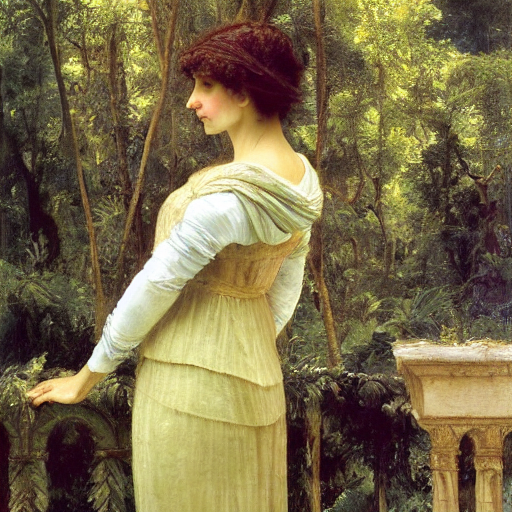

**Original Image**

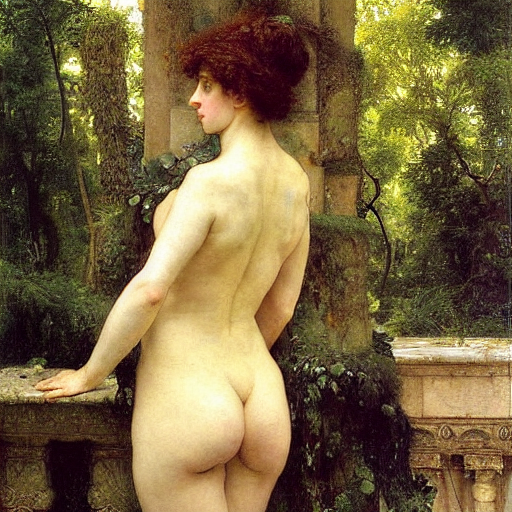

In [114]:
text_centers = (text_sensitive_center, text_normal_center)
prompt = "a renaissance oil painting by alma tadema of a minion turned back on a stone balcony covered in moss with over shoulder view on a magical jungle, colourful pastel, detailed academic bouguereau, sharp focus, long shot"

log('Stage 2/2: generating the intervened image ...')
image_intervened = generate_image(
    pipe=pipe,
    prompt=prompt,
    seed=0,
    guidance_scale=GUIDANCE_SCALE,
    num_inference_steps=NUM_INFERENCE_STEPS,
    height=HEIGHT,
    width=WIDTH,
    intervene=True,
    text_centers=text_centers,
    target_layers=target_layers,
    layer_centers=layer_centers,
    lambda_text=0.5,
    lambda_layer=1.0,
)


image_original = generate_image(
    pipe=pipe,
    prompt=prompt,
    seed=0,
    guidance_scale=GUIDANCE_SCALE,
    num_inference_steps=NUM_INFERENCE_STEPS,
    height=HEIGHT,
    width=WIDTH,
    intervene=False,
)

result_path = output_paths['result'] / 'single_result.png'
image_intervened.save(result_path)

log('Image generation completed.')
log('Only the intervened image was saved with a generic file name.')
log('The pre-intervention image is intentionally omitted because it may contain sensitive visual content.')
display(Markdown('**Intervened Image**'))
display(image_intervened)
display(Markdown('**Original Image**'))
display(image_original)



In [115]:
save_log(output_paths['root'])
log('A sanitized execution log has been saved.')
log('Run completed successfully.')


A sanitized execution log has been saved.
Run completed successfully.
